In [ ]:
from os import mkdir

import numpy as np
import matplotlib.pyplot as plt
import bionetgen
import roadrunner
from os import makedirs

# Embedded BNGL model template
bngl_template = """# MODEL 2 

# Ras-SOS Activation Model 2 - modified to remove positive feedback
# altered parameters for multimodality 
# increased Kcat2 and decreased Koff1 


begin model

begin parameters
    RhoSOS 30             # nM # initial RhoSOS parameter for scanning
    
    Kon1 7e-5*RhoSOS*A           # sos binding to corral
    
    Koff1 5e-3            # Dissociation rate for SOS from corral
    Kcat1 1e-2 / A        # Catalytic rate for RasGDP -> RasGTP
    Kcat2 2.5e-2          # Catalytic rate for RasGTP -> RasGDP.  # initial Kcat2 parameter in Model 2 = 2.5e-3 
    
    A {AREA}                   # Area, (µm²)
    RasTotal 1000 * A          # Total number of Ras molecules, initially all RasGDP 
    
end parameters

begin molecule types
    Ras(a~p~0)        
    Sos()             
end molecule types

begin species
    Ras(a~0) RasTotal     # Initial RasGDP molecules
end species

begin observables
    Molecules Sos_act Sos()
    Molecules Ras_act Ras(a~p)
end observables

begin reaction rules
    SosBinding:  0 <-> Sos() Kon1,Koff1
    RasPhos:        Ras(a~0) + Sos() -> Ras(a~p) + Sos() Kcat1
    RasDephos:      Ras(a~p) -> Ras(a~0) Kcat2
end reaction rules

end model


simulate({{method=>"ssa", t_end=>1000000, n_steps=>1000000}})
"""

# Setup
mbase = "Model2_noFB"
dirname = "results_Area_" + mbase
makedirs(dirname, exist_ok=True)
Areas = [1, 4, 9, 16, 25]

# Run all simulations
for A in Areas:
    # Create model file with specific area value
    bngl_content = bngl_template.replace("{AREA}", str(A))
    mfile = dirname + "/" + mbase + f"_A_{A}.bngl"
    
    with open(mfile, "w") as f:
        f.write(bngl_content)
    
    bionetgen.run(mfile, out=dirname)
    print(f"Completed simulation for Area={A}")

# Now load all the results from .gdat files
results = []
for A in Areas:
    gdat_file = f"{dirname}/{mbase}_A_{A}.gdat"
    data = np.genfromtxt(gdat_file, names=True)
    results.append(data)
    print(f"Loaded Area={A}: {len(data)} time points, Ras_act final={data['Ras_act'][-1]:.1f}")

Area=1, Sos_act: mean=0.43
Area=1, Ras_act: mean=114.45
Area=4, Sos_act: mean=1.68
Area=4, Ras_act: mean=540.52
Area=9, Sos_act: mean=3.83
Area=9, Ras_act: mean=1273.52
Area=16, Sos_act: mean=6.71
Area=16, Ras_act: mean=2263.84
Area=25, Sos_act: mean=10.67
Area=25, Ras_act: mean=3610.51


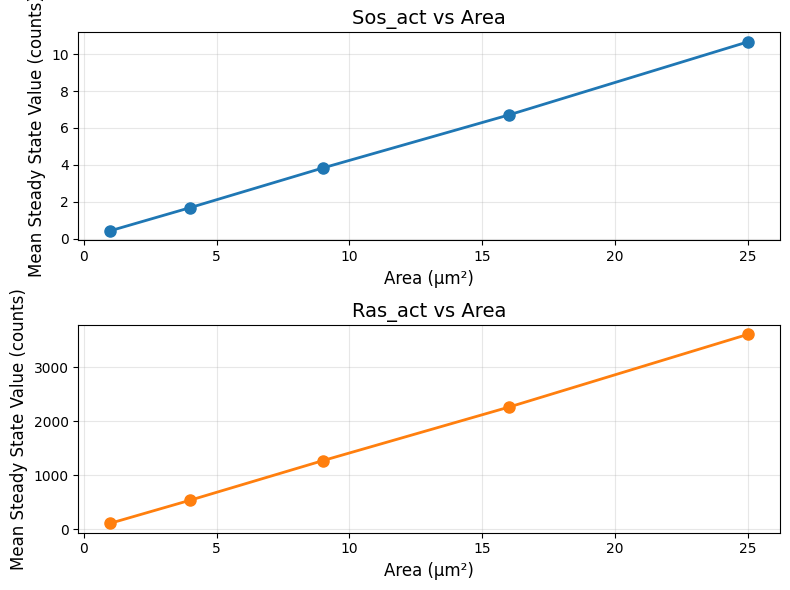

In [5]:
# Plot the mean steady state values of each observable as a function of area

# Get observable names from first result
observables = [name for name in results[0].dtype.names if name != "time"]

# Calculate mean steady state values (excluding first 20% of trajectory)
steady_state_means = {obs: [] for obs in observables}

for i, data in enumerate(results):
    # Exclude first 20% of time points (use last 80% for steady state)
    n_points = len(data)
    ss_start = int(0.2 * n_points)
    
    for obs in observables:
        ss_mean = np.mean(data[obs][ss_start:])
        steady_state_means[obs].append(ss_mean)
        print(f"Area={Areas[i]}, {obs}: mean={ss_mean:.2f}")

# Get default colors
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Create separate subplot for each observable
fig, axes = plt.subplots(len(observables), 1, figsize=(8, 3*len(observables)))

# Handle case of single observable
if len(observables) == 1:
    axes = [axes]

# Plot each observable in its own subplot
for i, obs in enumerate(observables):
    color = default_colors[i % len(default_colors)]
    axes[i].plot(Areas, steady_state_means[obs], 'o-', 
                color=color, linewidth=2, markersize=8)
    axes[i].set_xlabel("Area (µm²)", fontsize=12)
    axes[i].set_ylabel("Mean Steady State Value (counts)", fontsize=12)
    axes[i].set_title(f"{obs} vs Area", fontsize=14)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

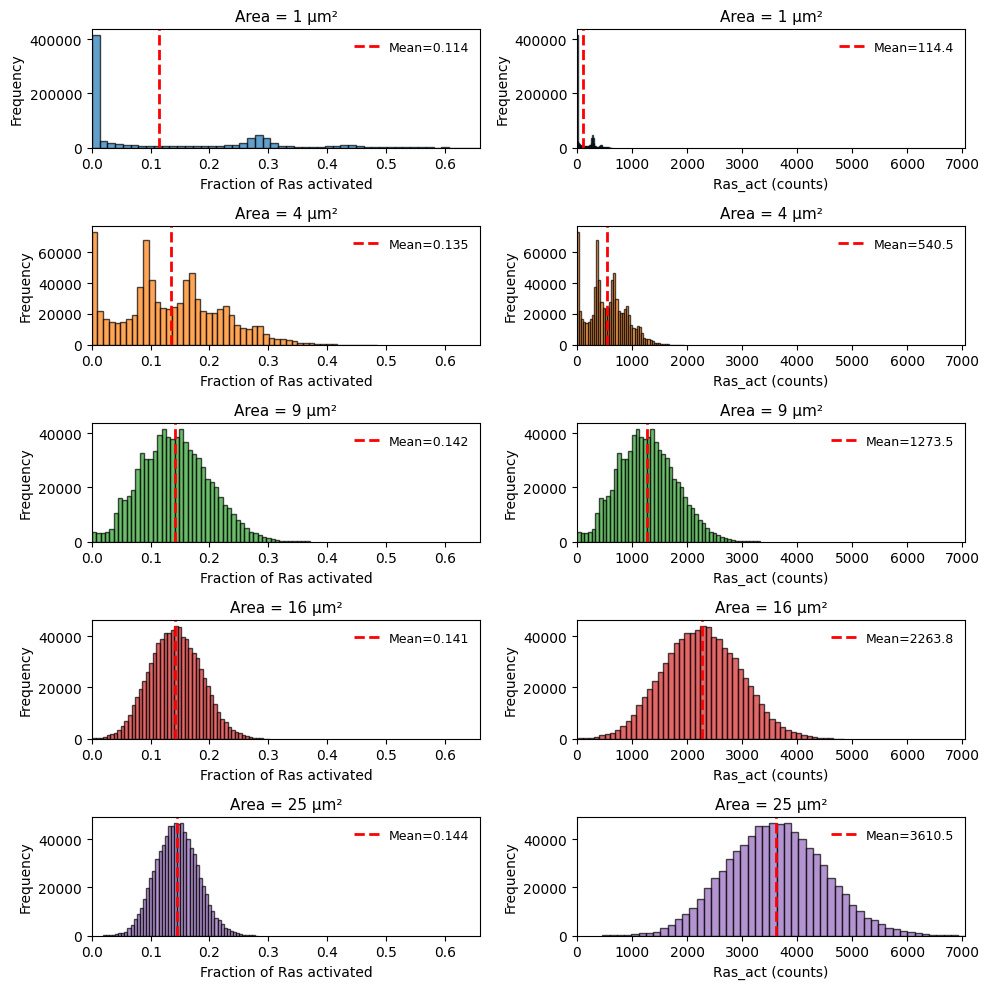

In [6]:
# Create table of histograms: rows = areas, columns = [fraction, absolute]

# First, collect all data to determine common x-axis ranges
all_fractions = []
all_absolutes = []

for i, data in enumerate(results):
    A = Areas[i]
    
    # Exclude first 20% of trajectory
    n_points = len(data)
    ss_start = int(0.2 * n_points)
    
    # Get steady state data
    ras_act_ss = data['Ras_act'][ss_start:]
    ras_total = 1000 * A
    fraction_ss = ras_act_ss / ras_total
    
    all_fractions.extend(fraction_ss)
    all_absolutes.extend(ras_act_ss)

# Determine common x-axis ranges
frac_min, frac_max = np.min(all_fractions), np.max(all_fractions)
abs_min, abs_max = np.min(all_absolutes), np.max(all_absolutes)

# Create figure with subplots: n_areas rows x 2 columns
n_areas = len(Areas)
fig, axes = plt.subplots(n_areas, 2, figsize=(10, 2*n_areas))

# Get default colors
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Create histograms for each area
for i, data in enumerate(results):
    A = Areas[i]
    
    # Exclude first 20% of trajectory
    n_points = len(data)
    ss_start = int(0.2 * n_points)
    
    # Get steady state data
    ras_act_ss = data['Ras_act'][ss_start:]
    ras_total = 1000 * A
    fraction_ss = ras_act_ss / ras_total
    
    # Calculate means
    mean_fraction = np.mean(fraction_ss)
    mean_absolute = np.mean(ras_act_ss)
    
    color = default_colors[i % len(default_colors)]
    
    # Column 1: Fraction histogram
    axes[i, 0].hist(fraction_ss, bins=50, color=color, alpha=0.7, edgecolor="black")
    axes[i, 0].axvline(mean_fraction, color='red', linestyle='--', linewidth=2, label=f'Mean={mean_fraction:.3f}')
    axes[i, 0].set_xlim(frac_min, frac_max)
    axes[i, 0].set_xlabel("Fraction of Ras activated", fontsize=10)
    axes[i, 0].set_ylabel("Frequency", fontsize=10)
    axes[i, 0].set_title(f"Area = {A} µm²", fontsize=11)
    axes[i, 0].legend(frameon=False, fontsize=9)
    
    # Column 2: Absolute count histogram
    axes[i, 1].hist(ras_act_ss, bins=50, color=color, alpha=0.7, edgecolor="black")
    axes[i, 1].axvline(mean_absolute, color='red', linestyle='--', linewidth=2, label=f'Mean={mean_absolute:.1f}')
    axes[i, 1].set_xlim(abs_min, abs_max)
    axes[i, 1].set_xlabel("Ras_act (counts)", fontsize=10)
    axes[i, 1].set_ylabel("Frequency", fontsize=10)
    axes[i, 1].set_title(f"Area = {A} µm²", fontsize=11)
    axes[i, 1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()